In [3]:
import numpy as np

In [4]:
def gini(y):
    """불순도: 0이면 완벽히 순수, 클수록 섞임"""
    if len(y) == 0:
        return 0.0
    # 각 클래스의 비율 계산
    classes, counts = np.unique(y, return_counts=True)
    # 각 클래스의 갯수(리스트) / 전체 갯수
    # print(classes, counts)
    p = counts / len(y)
    # p: 각 클래스의 비율의 리스트
    # 1 - np.sum(p**2) == 0 : 순수(클래스가 1개) 
    # 0.5 반반
    # print(counts, p)
    # print(np.sum(p ** 2))
    # print(1 - np.sum(p ** 2))
    return 1 - np.sum(p ** 2)

In [5]:
def split_gini(X_col, y, threshold):
    """X_col을 threshold 기준으로 좌/우로 나눴을 때의 가중 평균 Gini"""
    left = y[X_col <= threshold] # 기준값 이하 → 왼쪽
    right = y[X_col > threshold] # 기준값 초과 → 오른쪽

    n = len(y)
    # 좌/우 그룹 크기로 가중 평균
    # print(left, len(left) / n, gini(left))
    # print(right, len(right) / n, gini(right))
    weighted = (len(left) / n) * gini(left) + (len(right) / n) * gini(right)
    return weighted

In [14]:
def best_split(X, y):
    """모든 피처 x 모든 기준값을 시도해 Gini가 최소가 되는 분할을 찾는다"""
    best = {"gini": float("inf"), "feature": None, "threshold": None}
    # float("inf"): 무한대. 첫 비교에서 무조건 갱신되도록 시작값을 최대로 둠

    n_features = X.shape[1]
    # print(n_features)
    for feat in range(n_features):
        # print("feat", feat)
        thresholds = np.unique(X[:, feat])
        # print("thresholds", thresholds)
        for t in thresholds:
            # print("element", t)
            g = split_gini(X[:, feat], y, t)
            # print(f" 피처{feat}, 기준{t}: gini={g:.4f}")
            if g < best["gini"]:
                best = {"gini": g, "feature": feat, "threshold": t}
                # print(best)
    return best

In [15]:
def build_tree(X, y, depth=0, max_depth=None):
    # --- 멈춤 조건 (base case) ---
    # 1) 이미 순수하면 (한 클래스만 남음) → 잎으로 종료
    if len(np.unique(y)) == 1:
        return {"leaf": y[0]}

    # 2) 최대 깊이 도달 → 잎으로 종료 (다수결로 예측값 결정)
    if max_depth is not None and depth >= max_depth:
        values, counts = np.unique(y, return_counts=True)
        return {"leaf": values[np.argmax(counts)]} # 가장 많은 클래스

    # --- 분할 (recursive case) ---
    split = best_split(X, y)
    feat, thr = split["feature"], split["threshold"]

    # 좌/우로 데이터 나누기
    left_mask = X[:, feat] <= thr
    right_mask = ~left_mask

    # 자식도 똑같이 build_tree로 
    left_child = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    right_child = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return {
        "feature": feat,
        "threshold": thr,
        "left": left_child,
        "right": right_child,
    }

In [18]:
X = np.array([
    [1, 5], 
    [2, 9], 
    [3, 2], 
    [8, 7], 
    [9, 1], 
    [10, 6]
])
y = np.array([0, 0, 0, 1, 1, 1])

tree = build_tree(X, y)
print(tree)

{'feature': 0, 'threshold': np.int64(3), 'left': {'leaf': np.int64(0)}, 'right': {'leaf': np.int64(1)}}


In [19]:
tree?

Type:        dict
String form: {'feature': 0, 'threshold': np.int64(3), 'left': {'leaf': np.int64(0)}, 'right': {'leaf': np.int64(1)}}
Length:      4
Docstring:  
dict() -> new empty dictionary
dict(mapping) -> new dictionary initialized from a mapping object's
    (key, value) pairs
dict(iterable) -> new dictionary initialized as if via:
    d = {}
    for k, v in iterable:
        d[k] = v
dict(**kwargs) -> new dictionary initialized with the name=value pairs
    in the keyword argument list.  For example:  dict(one=1, two=2)

### build_tree 실행 과정 도식화

**입력 데이터**
```
     피처0  피처1   라벨
     [ 1,    5  ]    0
     [ 2,    9  ]    0     ← 클래스 0 (피처0 작음)
     [ 3,    2  ]    0
     [ 8,    7  ]    1
     [ 9,    1  ]    1     ← 클래스 1 (피처0 큼)
     [10,    6  ]    1
```

**재귀 호출 흐름**
```
build_tree(X전체, y=[0,0,0,1,1,1], depth=0)
│
├─ 멈춤조건: unique([0,0,0,1,1,1])=[0,1] → 2개 클래스, 안 순수 ❌
│
├─ best_split → {feature:0, threshold:3}  (05에서 검증: gini=0)
│
├─ 나누기: left_mask = X[:,0] <= 3 → [T,T,T,F,F,F]
│          right_mask = ~left_mask  → [F,F,F,T,T,T]
│
├──────────────┬───────────────────┐
▼              ▼                   ▼
왼쪽 재귀                     오른쪽 재귀
build_tree(              build_tree(
  y=[0,0,0], depth=1)       y=[1,1,1], depth=1)
│                        │
├─ unique([0,0,0])=[0]    ├─ unique([1,1,1])=[1]
│  → 순수 ✅              │  → 순수 ✅
▼                        ▼
{"leaf": 0}              {"leaf": 1}
```

**조립된 최종 트리**
```
           [피처0 <= 3?]          ← depth 0 (분할 노드)
           /          \
        예 /            \ 아니오
    {leaf: 0}        {leaf: 1}    ← depth 1 (잎, 순수해서 종료)
```

→ 딕셔너리로 표현:
`{'feature': 0, 'threshold': 3, 'left': {'leaf': 0}, 'right': {'leaf': 1}}`

**핵심**: 재귀가 좌/우로 자기 자신을 호출하며, 각 그룹이 **순수해질 때(gini=0)까지** 자동으로 파고든다. 이 데이터는 한 번에 완벽히 갈려 depth 1에서 종료. 더 복잡했다면 순수해질 때까지 계속 내려갔을 것. — "0이 될 때까지 반복"이 재귀로 구현된 것.


In [21]:
def predict_tree(node, x):
    """딕셔너리 트리(node)를 타고 내려가 x 한 개를 예측"""
    # --- 멈춤 조건: 잎에 도착하면 그 값 반환 ---
    if "leaf" in node:
        return node["leaf"]

    # --- 분할 노드: 질문에 따라 좌/우로 ---
    feat = node["feature"]
    thr = node["threshold"]

    if x[feat] <= thr:              # 기준값 이하 → 왼쪽
        return predict_tree(node["left"], x)
    else:                           # 기준값 초과 → 오른쪽
        return predict_tree(node["right"], x)

In [24]:
def predict(tree, X):
    """X의 모든 샘플을 예측 (predict_tree를 각 행에 적용)"""
    return np.array([predict_tree(tree, x) for x in X])

In [25]:
# 앞서 만든 tree 재사용
X = np.array([
    [1,5],
    [2,9],
    [3,2],
    [8,7],
    [9,1],
    [10,6]
])
y = np.array([0, 0, 0, 1, 1, 1])

pred = predict(tree, X)
print("예측:", pred)
print("실제:", y)
print("정확도:", (pred == y).mean())

# 새로운 데이터
new = np.array([[2, 100], [9, 0]])
print("새 데이터 예측:", predict(tree, new))

예측: [0 0 0 1 1 1]
실제: [0 0 0 1 1 1]
정확도: 1.0
새 데이터 예측: [0 1]


In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

bc = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, stratify=bc.target, random_state=42
)

# 직접 구현
my_tree = build_tree(X_train, y_train)
my_pred = predict(my_tree, X_test)
my_acc = (my_pred == y_test).mean()

# sklearn (제한 없이 = 내 구현과 같은 조건)
sk = DecisionTreeClassifier(random_state=42)
sk.fit(X_train, y_train)
sk_acc = sk.score(X_test, y_test)

print(f"내 구현: {my_acc:.4f}")
print(f"sklearn: {sk_acc:.4f}")

내 구현: 0.9298
sklearn: 0.9123


In [31]:
# 내 트리의 정확도
train_acc = (predict(my_tree, X_train) == y_train).mean()
print(f"내 구현 train: {train_acc:.4f}") # 1.0 예상
print(f"내 구현 test: {my_acc:.4f}")

내 구현 train: 1.0000
내 구현 test: 0.9298


In [29]:
def bootstrap_sample(X, y):
    """복원추출: 같은 크기지만 중복 허용해 무작위로 뽑음"""
    n = len(X)
    idx = np.random.choice(n, size=n, replace=True) # 0~n-1에서 n개, 중복 O
    return X[idx], y[idx]

In [30]:
def build_forest(X, y, n_trees=10):
    """n_trees개의 트리를, 각자 다른 bootstrap 샘플로 학습"""
    forest = []
    for _ in range(n_trees):
        Xs, ys = bootstrap_sample(X, y)
        tree = build_tree(Xs, ys)
        forest.append(tree)
    return forest

In [32]:
def predict_forest(forest, X):
    """모든 트리의 예측을 모아 다수결로 최종 결정"""
    # 각 트리가 X 전체를 예측 → (트리수 x 샘플수) 행렬
    all_preds = np.array([predict(tree, X) for tree in forest])
    # 예: 트리 3개, 샘플 4개면
    #   [[0,1,1,0],     ← 트리 1의 예측
    #    [0,1,0,0],     ← 트리 2
    #    [1,1,1,0]]     ← 트리 3

    # 각 샘플(열)마다 다수결
    n_samples = X.shape[0]
    final = []
    for i in range(n_samples):
        col = all_preds[:, i]                     # i번째 샘플에 대한 모든 트리 예측
        values, counts = np.unique(col, return_counts=True)
        final.append(values[np.argmax(counts)])   # 가장 표를 많이 받은 클래스
    return np.array(final)

In [33]:
np.random.seed(42)   # 재현성 (bootstrap이 무작위라 매번 달라지는 것 방지)

# 숲 만들기 (트리 10그루)
forest = build_forest(X_train, y_train, n_trees=10)

# 숲으로 예측
forest_pred = predict_forest(forest, X_test)
forest_acc = (forest_pred == y_test).mean()

print(f"트리 한 그루 test: {my_acc:.4f}")   
print(f"숲 (10그루) test: {forest_acc:.4f}")

트리 한 그루 test: 0.9298
숲 (10그루) test: 0.9386


In [34]:
np.random.seed(42)   # 재현성 (bootstrap이 무작위라 매번 달라지는 것 방지)

# 숲 만들기 (트리 50그루)
forest = build_forest(X_train, y_train, n_trees=50)

# 숲으로 예측
forest_pred = predict_forest(forest, X_test)
forest_acc = (forest_pred == y_test).mean()

print(f"트리 한 그루 test: {my_acc:.4f}")   
print(f"숲 (10그루) test: {forest_acc:.4f}")

트리 한 그루 test: 0.9298
숲 (10그루) test: 0.9561


In [35]:
from sklearn.ensemble import RandomForestClassifier

# sklearn 랜덤포레스트 (같은 조건: 트리 50그루)
sk_rf = RandomForestClassifier(n_estimators=50, random_state=42)
sk_rf.fit(X_train, y_train)
sk_rf_acc = sk_rf.score(X_test, y_test)

print(f"내 구현 숲 (50그루):    {forest_acc:.4f}")
print(f"sklearn RF (50그루):   {sk_rf_acc:.4f}")


내 구현 숲 (50그루):    0.9561
sklearn RF (50그루):   0.9561


트리   1개: 0.9035
트리   5개: 0.9123
트리  10개: 0.9386
트리  20개: 0.9474
트리  50개: 0.9561
트리 100개: 0.9561


C:\dev\sesac\ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\sesac\ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\sesac\ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\sesac\ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\dev\sesac\ml\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\d

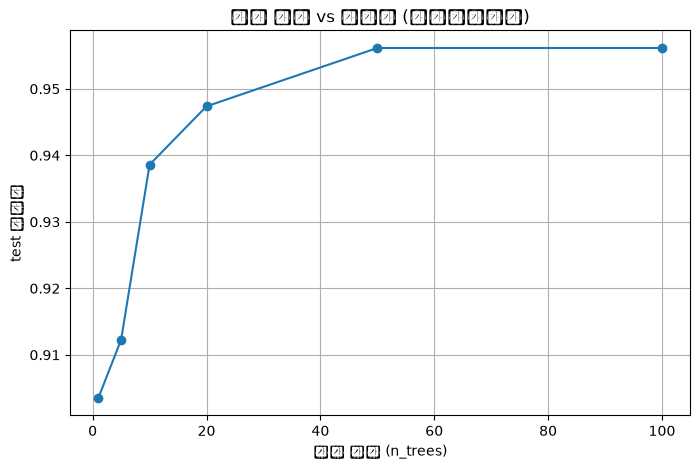

In [36]:
import matplotlib.pyplot as plt

n_trees_list = [1, 5, 10, 20, 50, 100]
accuracies = []

for n in n_trees_list:
    np.random.seed(42)                          # 매번 같은 조건에서 비교
    forest = build_forest(X_train, y_train, n_trees=n)
    pred = predict_forest(forest, X_test)
    acc = (pred == y_test).mean()
    accuracies.append(acc)
    print(f"트리 {n:3d}개: {acc:.4f}")




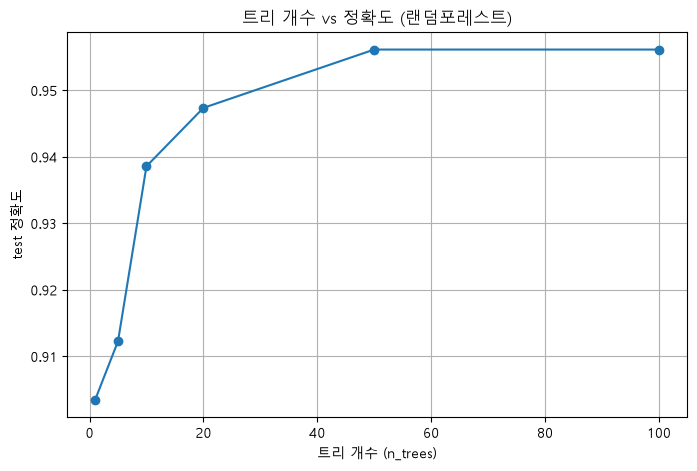

In [37]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호(-) 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 곡선 그리기
plt.figure(figsize=(8, 5))
plt.plot(n_trees_list, accuracies, marker="o")
plt.xlabel("트리 개수 (n_trees)")
plt.ylabel("test 정확도")
plt.title("트리 개수 vs 정확도 (랜덤포레스트)")
plt.grid(True)
plt.show()


## 결론: 밑바닥부터 랜덤포레스트

### 만든 것
| 함수 | 역할 |
|---|---|
| `build_tree` / `predict_tree` | 재귀로 트리 만들기 / 예측 (05의 best_split 활용) |
| `bootstrap_sample` | 복원추출로 데이터 무작위 |
| `build_forest` / `predict_forest` | 여러 트리 학습 + 다수결 |

### 검증
- 내 구현 숲(50그루) = **0.9561** = sklearn RandomForest(50그루) → 원리 일치 ✅

### 핵심 발견
1. **숲 > 한 그루**: 한 그루(0.90) → 50그루(0.96).
   각 트리가 다른 bootstrap으로 다르게 틀리고, 다수결로 오류가 상쇄됨.
2. **트리 개수는 수렴한다**: 1→50까지 오르다 50→100은 변화 없음(0.9561).
   → sklearn n_estimators 기본값 100의 근거. 그 이상은 계산만 늘고 이득 없음.
3. **트리 개수 vs 깊이 성격 반대**:
   - n_estimators ↑ → 안전 (수렴만)
   - max_depth ↑ → 위험 (과적합)

### 실제 라이브러리와의 차이 (원리는 같고 실행만 다름)
- Cython/C++ 컴파일 (순수 Python 재귀보다 수십~수백 배 빠름)
- 정렬 기반 분할, 병렬화(n_jobs), 히스토그램 bin(XGBoost 등)
→ "무엇을(what)"은 동일, "어떻게 빠르게(how)"만 최적화.
